## Importing the relevant packages


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.graphics.tsaplots as sgt
from statsmodels.tsa.arima.model import ARIMA
from scipy.stats.distributions import chi2
import statsmodels.tsa.stattools as sts 
import seaborn as sns
sns.set()

## Importing the Data and Pre-processing 

In [3]:
raw_csv_data = pd.read_csv("Index2018.csv") 
df_comp=raw_csv_data.copy()
df_comp.date = pd.to_datetime(df_comp.date, dayfirst = True)
df_comp.set_index("date", inplace=True)
df_comp=df_comp.asfreq('b')
df_comp=df_comp.ffill()

In [4]:
df_comp['market_value']=df_comp.ftse

In [5]:
del df_comp['spx']
del df_comp['dax']
del df_comp['ftse']
del df_comp['nikkei']
size = int(len(df_comp)*0.8)
df, df_test = df_comp.iloc[:size], df_comp.iloc[size:]

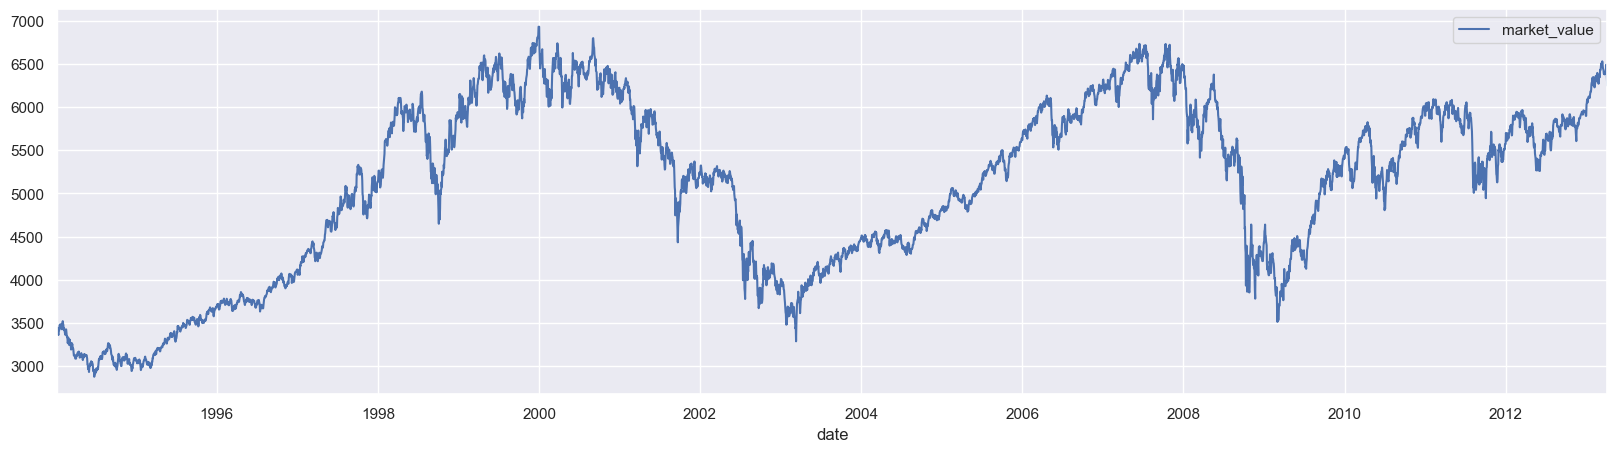

In [8]:
df.plot(figsize=(20,5))
plt.show()

## LLR Test

In [9]:
def LLR_test(mod_1, mod_2, DF=1):
    L1 = mod_1.fit().llf
    L2 = mod_2.fit().llf
    LR = (2*(L2-L1))
    p = chi2.sf(LR, DF).round(3)
    return p

## The DF-Test

In [10]:
# Using Dickey-Fuller Test To Check if the FTSE Prices are Stationary or Non-Stationary
sts.adfuller(df.market_value)

(np.float64(-1.904155141883686),
 np.float64(0.3301089327702835),
 6,
 5014,
 {'1%': np.float64(-3.4316548765428174),
  '5%': np.float64(-2.8621166146845334),
  '10%': np.float64(-2.5670769326348926)},
 np.float64(54854.15304507557))

`We see that p value is -> 0.330 > 0.05 implies that we cannot reject the hypothesis -> Prices is Non Stationary`

## Using Returns

`Returns means Percentage change between the current price and previous price`                                             
`Positive Return -> prices increased`                                                                                       
`Negative Return -> prices decreased`                                                                                       

In [ ]:
# we use .pct_change(lag) 
df['returns'] = df.market_value.pct_change(1).mul(100) #mul(X) means multiply series by X on entire series

In [13]:
# since the first row is NaN we make the df from row =1 instead
df = df.iloc[1:]

In [14]:
df.head()

,market_value,returns
date,,
1994-01-10,3440.58,-0.156704
1994-01-11,3413.77,-0.779229
1994-01-12,3372.02,-1.222988
1994-01-13,3360.01,-0.356166
1994-01-14,3400.56,1.206842


**Augmented Dickey-Fuller Test On Returns**

In [15]:
sts.adfuller(df.returns)

(np.float64(-12.770265719497264),
 np.float64(7.798058336037375e-24),
 32,
 4987,
 {'1%': np.float64(-3.431661944885779),
  '5%': np.float64(-2.8621197374408225),
  '10%': np.float64(-2.5670785949998973)},
 np.float64(15696.767245697501))

`We clearly see that p value is Significantly less than 0.05 -> The returns data is infact Stationary`                     
`-> we can run AR models and other models to predict the returns now!!`

## ACF and PACF for Returns

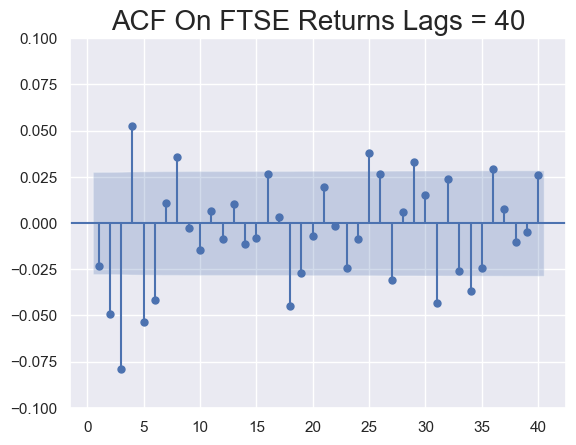

In [19]:
sgt.plot_acf(df.returns, lags=40, zero=False)
plt.title("ACF On FTSE Returns Lags = 40",size=20)
plt.ylim(-.1,.1)
plt.show()

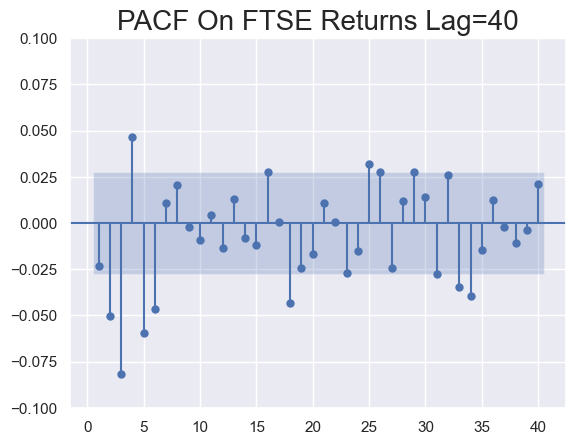

In [21]:
sgt.plot_pacf(df.returns, lags =40, zero=False,alpha=0.05, method=('ols'))
plt.ylim(-.1,.1)
plt.title("PACF On FTSE Returns Lag=40",size=20)
plt.show()

## AR(1) for Returns

In [28]:
ret_ar = ARIMA(df.returns, order=(1,0,0)) # Pure AR1 Model on returns 

In [29]:
res_ar = ret_ar.fit() # AR(1) Model Summary
print(res_ar.summary())

                               SARIMAX Results                                
Dep. Variable:                returns   No. Observations:                 5020
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -7929.749
Date:                Sun, 26 Apr 2026   AIC                          15865.497
Time:                        15:19:49   BIC                          15885.061
Sample:                    01-10-1994   HQIC                         15872.353
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0188      0.016      1.143      0.253      -0.013       0.051
ar.L1         -0.0230      0.009     -2.697      0.007      -0.040      -0.006
sigma2         1.3790      0.014    100.092      0.0

## Higher-Lag AR Models for Returns

In [30]:
ret_ar_2 = ARIMA(df.returns, order=(2,0,0))
res_ar_2 = ret_ar_2.fit()
print(res_ar_2.summary())

                               SARIMAX Results                                
Dep. Variable:                returns   No. Observations:                 5020
Model:                 ARIMA(2, 0, 0)   Log Likelihood               -7923.456
Date:                Sun, 26 Apr 2026   AIC                          15854.911
Time:                        15:32:11   BIC                          15880.996
Sample:                    01-10-1994   HQIC                         15864.052
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0188      0.016      1.194      0.233      -0.012       0.050
ar.L1         -0.0242      0.009     -2.799      0.005      -0.041      -0.007
ar.L2         -0.0500      0.008     -6.371      0.0

In [ ]:
# LLR TEST TO CHECK IF THE HIGHER MODEL IS A BETTER FIT
LLR_test(ret_ar,ret_ar_2) 
# <0.01 implies AR(2) > AR(1)

np.float64(0.0)

In [31]:
ret_ar_3 = ARIMA(df.returns, order=(3,0,0))
res_ar_3 = ret_ar_3.fit()
print(res_ar_3.summary())

                               SARIMAX Results                                
Dep. Variable:                returns   No. Observations:                 5020
Model:                 ARIMA(3, 0, 0)   Log Likelihood               -7906.738
Date:                Sun, 26 Apr 2026   AIC                          15823.477
Time:                        15:33:12   BIC                          15856.083
Sample:                    01-10-1994   HQIC                         15834.902
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0189      0.015      1.272      0.203      -0.010       0.048
ar.L1         -0.0283      0.009     -3.199      0.001      -0.046      -0.011
ar.L2         -0.0521      0.008     -6.684      0.0

In [ ]:
LLR_test(ret_ar_2, ret_ar_3) # again AR(3) > AR(2)

np.float64(0.0)

In [32]:
ret_ar_4 = ARIMA(df.returns, order=(4,0,0))
res_ar_4 = ret_ar_4.fit()
print(res_ar_4.summary())

                               SARIMAX Results                                
Dep. Variable:                returns   No. Observations:                 5020
Model:                 ARIMA(4, 0, 0)   Log Likelihood               -7901.330
Date:                Sun, 26 Apr 2026   AIC                          15814.661
Time:                        15:33:46   BIC                          15853.788
Sample:                    01-10-1994   HQIC                         15828.371
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0188      0.016      1.208      0.227      -0.012       0.049
ar.L1         -0.0245      0.009     -2.770      0.006      -0.042      -0.007
ar.L2         -0.0496      0.008     -6.327      0.0

In [ ]:
LLR_test(ret_ar_3, ret_ar_4) # still less than 0.01 -> AR(4) > AR(3)

np.float64(0.001)

In [33]:
ret_ar_5 = ARIMA(df.returns, order=(5,0,0))
res_ar_5 = ret_ar_5.fit()
print(res_ar_5.summary())

                               SARIMAX Results                                
Dep. Variable:                returns   No. Observations:                 5020
Model:                 ARIMA(5, 0, 0)   Log Likelihood               -7892.390
Date:                Sun, 26 Apr 2026   AIC                          15798.779
Time:                        15:34:07   BIC                          15844.428
Sample:                    01-10-1994   HQIC                         15814.775
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0189      0.015      1.273      0.203      -0.010       0.048
ar.L1         -0.0217      0.009     -2.396      0.017      -0.040      -0.004
ar.L2         -0.0544      0.008     -6.826      0.0

In [ ]:
LLR_test(ret_ar_4, ret_ar_5) # AR(5) > AR(4)

np.float64(0.0)

In [35]:
ret_ar_6 = ARIMA(df.returns, order=(6,0,0))
res_ar_6 = ret_ar_6.fit()
print(res_ar_6.summary())

                               SARIMAX Results                                
Dep. Variable:                returns   No. Observations:                 5020
Model:                 ARIMA(6, 0, 0)   Log Likelihood               -7886.945
Date:                Sun, 26 Apr 2026   AIC                          15789.890
Time:                        15:34:54   BIC                          15842.059
Sample:                    01-10-1994   HQIC                         15808.170
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0189      0.014      1.324      0.186      -0.009       0.047
ar.L1         -0.0245      0.009     -2.640      0.008      -0.043      -0.006
ar.L2         -0.0523      0.008     -6.505      0.0

In [ ]:
LLR_test(ret_ar_5, ret_ar_6) # AR(6) > AR(5)

np.float64(0.001)

In [34]:
ret_ar_7 = ARIMA(df.returns, order=(7,0,0))
res_ar_7 = ret_ar_7.fit()
print(res_ar_7.summary())

                               SARIMAX Results                                
Dep. Variable:                returns   No. Observations:                 5020
Model:                 ARIMA(7, 0, 0)   Log Likelihood               -7886.647
Date:                Sun, 26 Apr 2026   AIC                          15791.294
Time:                        15:34:52   BIC                          15849.985
Sample:                    01-10-1994   HQIC                         15811.860
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0189      0.015      1.304      0.192      -0.010       0.047
ar.L1         -0.0240      0.009     -2.579      0.010      -0.042      -0.006
ar.L2         -0.0517      0.008     -6.375      0.0

In [ ]:
LLR_test(ret_ar_6, ret_ar_7)
# clearly we see that AR(7) is not a better fit than AR(6)

np.float64(0.44)

#### Conclusion: 
`(i) Log likelihood increased till AR(6)`                                                                                
`(ii) Information Criteria decreased till AR(6)`                                                                          
`(iii) Last lag value was significant till AR(6)`                                                                         
`(iv) LLR Test value is not significant when comparing AR(6) and AR(7) i.e >0.01 -> AR(7) is not significantly different than AR(6)`      

`-> The best fit among all the AR models is AR(6)`

## Normalizing Values

In [43]:
first_val = df.market_value.iloc[0]

In [ ]:
df['norm'] = df.market_value.div(first_val).mul(100)

In [45]:
df.norm

date
1994-01-10    100.000000
1994-01-11     99.220771
1994-01-12     98.007313
1994-01-13     97.658244
1994-01-14     98.836824
                 ...    
2013-04-01    186.356370
2013-04-02    188.650169
2013-04-03    186.604584
2013-04-04    184.390713
2013-04-05    181.648734
Freq: B, Name: norm, Length: 5020, dtype: float64

In [46]:
# To check the stationarity of Normalized FTSE prices, we use Augmented Dickey-Fuller Test
sts.adfuller(df.norm)

(np.float64(-1.8928710132672342),
 np.float64(0.33542220743300766),
 6,
 5013,
 {'1%': np.float64(-3.431655136974821),
  '5%': np.float64(-2.8621167297421373),
  '10%': np.float64(-2.567076993884522)},
 np.float64(19553.90073102193))

`Clearly the p value is > 0.05 implies the normalized prices are Not Stationary`                                           
`Thus -> Cannot fit the models on this normalized prices` 

## Normalized Returns

In [47]:
first_ret = df.returns.iloc[0]

In [ ]:
df['norm_ret'] = df.returns.div(first_ret).mul(100)

In [50]:
# Checking Stationarity again on normalized returns
sts.adfuller(df.norm_ret)

(np.float64(-12.770265719497257),
 np.float64(7.798058336037547e-24),
 32,
 4987,
 {'1%': np.float64(-3.431661944885779),
  '5%': np.float64(-2.8621197374408225),
  '10%': np.float64(-2.5670785949998973)},
 np.float64(80114.49116124898))

`Clearly the data is Stationary -> we can fit the models on this data`

### Fitting Models From AR(1) to AR(p) and check which fits the best

In [51]:
model_norm_ret_ar_1 = ARIMA(df.norm_ret, order=(1,0,0))
res_norm_ret_ar_1 = model_norm_ret_ar_1.fit()
print(res_norm_ret_ar_1.summary())
print()


                               SARIMAX Results                                
Dep. Variable:               norm_ret   No. Observations:                 5020
Model:                 ARIMA(1, 0, 0)   Log Likelihood              -40351.743
Date:                Sun, 26 Apr 2026   AIC                          80709.487
Time:                        16:17:21   BIC                          80729.050
Sample:                    01-10-1994   HQIC                         80716.342
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -11.9731     10.476     -1.143      0.253     -32.506       8.560
ar.L1         -0.0230      0.009     -2.697      0.007      -0.040      -0.006
sigma2      5.617e+05   5612.960    100.071      0.0

In [52]:
model_norm_ret_ar_2 = ARIMA(df.norm_ret, order=(2,0,0))
res_norm_ret_ar_2 = model_norm_ret_ar_2.fit()
print(res_norm_ret_ar_2.summary())
print()
print(f'LLR p value Result -> {LLR_test(model_norm_ret_ar_1,model_norm_ret_ar_2)}')


                               SARIMAX Results                                
Dep. Variable:               norm_ret   No. Observations:                 5020
Model:                 ARIMA(2, 0, 0)   Log Likelihood              -40345.450
Date:                Sun, 26 Apr 2026   AIC                          80698.901
Time:                        16:18:17   BIC                          80724.986
Sample:                    01-10-1994   HQIC                         80708.041
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -11.9731     10.050     -1.191      0.234     -31.671       7.725
ar.L1         -0.0242      0.009     -2.797      0.005      -0.041      -0.007
ar.L2         -0.0500      0.008     -6.368      0.0

In [53]:
model_norm_ret_ar_3 = ARIMA(df.norm_ret, order=(3,0,0))
res_norm_ret_ar_3 = model_norm_ret_ar_3.fit()
print(res_norm_ret_ar_3.summary())
print()
print(f'LLR p value Result -> {LLR_test(model_norm_ret_ar_2,model_norm_ret_ar_3)}')


                               SARIMAX Results                                
Dep. Variable:               norm_ret   No. Observations:                 5020
Model:                 ARIMA(3, 0, 0)   Log Likelihood              -40328.733
Date:                Sun, 26 Apr 2026   AIC                          80667.466
Time:                        16:19:04   BIC                          80700.072
Sample:                    01-10-1994   HQIC                         80678.892
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -11.9731      9.474     -1.264      0.206     -30.543       6.597
ar.L1         -0.0282      0.009     -3.193      0.001      -0.046      -0.011
ar.L2         -0.0520      0.008     -6.678      0.0

In [54]:
model_norm_ret_ar_4 = ARIMA(df.norm_ret, order=(4,0,0))
res_norm_ret_ar_4 = model_norm_ret_ar_4.fit()
print(res_norm_ret_ar_4.summary())
print()
print(f'LLR p value Result -> {LLR_test(model_norm_ret_ar_3,model_norm_ret_ar_4)}')


                               SARIMAX Results                                
Dep. Variable:               norm_ret   No. Observations:                 5020
Model:                 ARIMA(4, 0, 0)   Log Likelihood              -40323.325
Date:                Sun, 26 Apr 2026   AIC                          80658.650
Time:                        16:19:21   BIC                          80697.777
Sample:                    01-10-1994   HQIC                         80672.361
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -11.9731      9.957     -1.202      0.229     -31.489       7.543
ar.L1         -0.0245      0.009     -2.769      0.006      -0.042      -0.007
ar.L2         -0.0496      0.008     -6.325      0.0

In [55]:
model_norm_ret_ar_5 = ARIMA(df.norm_ret, order=(5,0,0))
res_norm_ret_ar_5 = model_norm_ret_ar_5.fit()
print(res_norm_ret_ar_5.summary())
print()
print(f'LLR p value Result -> {LLR_test(model_norm_ret_ar_4,model_norm_ret_ar_5)}')


                               SARIMAX Results                                
Dep. Variable:               norm_ret   No. Observations:                 5020
Model:                 ARIMA(5, 0, 0)   Log Likelihood              -40314.385
Date:                Sun, 26 Apr 2026   AIC                          80642.769
Time:                        16:19:47   BIC                          80688.418
Sample:                    01-10-1994   HQIC                         80658.765
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -11.9731      9.468     -1.265      0.206     -30.531       6.585
ar.L1         -0.0217      0.009     -2.395      0.017      -0.040      -0.004
ar.L2         -0.0544      0.008     -6.823      0.0

In [56]:
model_norm_ret_ar_6 = ARIMA(df.norm_ret, order=(6,0,0))
res_norm_ret_ar_6 = model_norm_ret_ar_6.fit()
print(res_norm_ret_ar_6.summary())
print()
print(f'LLR p value Result -> {LLR_test(model_norm_ret_ar_5,model_norm_ret_ar_6)}')


                               SARIMAX Results                                
Dep. Variable:               norm_ret   No. Observations:                 5020
Model:                 ARIMA(6, 0, 0)   Log Likelihood              -40308.940
Date:                Sun, 26 Apr 2026   AIC                          80633.880
Time:                        16:20:12   BIC                          80686.050
Sample:                    01-10-1994   HQIC                         80652.161
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -11.9731      9.123     -1.312      0.189     -29.854       5.908
ar.L1         -0.0245      0.009     -2.639      0.008      -0.043      -0.006
ar.L2         -0.0523      0.008     -6.501      0.0

In [57]:
model_norm_ret_ar_7 = ARIMA(df.norm_ret, order=(7,0,0))
res_norm_ret_ar_7 = model_norm_ret_ar_7.fit()
print(res_norm_ret_ar_7.summary())
print()
print(f'LLR p value Result -> {LLR_test(model_norm_ret_ar_6,model_norm_ret_ar_7)}')


                               SARIMAX Results                                
Dep. Variable:               norm_ret   No. Observations:                 5020
Model:                 ARIMA(7, 0, 0)   Log Likelihood              -40308.642
Date:                Sun, 26 Apr 2026   AIC                          80635.285
Time:                        16:20:29   BIC                          80693.975
Sample:                    01-10-1994   HQIC                         80655.851
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -11.9731      9.262     -1.293      0.196     -30.126       6.179
ar.L1         -0.0240      0.009     -2.577      0.010      -0.042      -0.006
ar.L2         -0.0517      0.008     -6.370      0.0

In [58]:
# LLR Test on AR(1) and AR(6) 
print(f'LLR p value -> {LLR_test(model_norm_ret_ar_1,model_norm_ret_ar_6,DF = 5)}')

LLR p value -> 0.0


`This tells us the best fitting model is AR(6) Model on normalized Returns of FTSE prices`

**This also tells us that using normalized returns gave us no significant benefits**

## Analysing the Residuals

### Checking Residuals on Prices

`AR(7) was the best fit model for prices`

In [64]:
model_ar_7 = ARIMA(df.market_value,order=(7,0,0))
price_res_ar_7 = model_ar_7.fit()
print(price_res_ar_7.summary())

                               SARIMAX Results                                
Dep. Variable:           market_value   No. Observations:                 5020
Model:                 ARIMA(7, 0, 0)   Log Likelihood              -27587.016
Date:                Sun, 26 Apr 2026   AIC                          55192.033
Time:                        16:56:31   BIC                          55250.724
Sample:                    01-10-1994   HQIC                         55212.599
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       5089.9683    407.297     12.497      0.000    4291.680    5888.257
ar.L1          0.9783      0.010     95.725      0.000       0.958       0.998
ar.L2         -0.0304      0.014     -2.182      0.0

In [ ]:
# Finding the residuals of the AR model of order 7 for prices
df['resid_price'] = price_res_ar_7.resid

In [68]:
df.head()

,market_value,returns,norm,norm_ret,resid_price,resid_returns
date,,,,,,
1994-01-10,3440.58,-0.156704,100.000000,100.000000,-1649.388287,-0.175613
1994-01-11,3413.77,-0.779229,99.220771,497.260711,-29.933468,-0.802187
1994-01-12,3372.02,-1.222988,98.007313,780.443046,-45.328481,-1.270015
1994-01-13,3360.01,-0.356166,97.658244,227.285567,-17.115247,-0.466046
1994-01-14,3400.56,1.206842,98.836824,-770.139292,33.397636,1.061295


In [70]:
# Checking mean and variances on residuals of prices
print(df.resid_price.mean())
print(df.resid_price.var())

0.3522785794772424
4010.3580586708285


`We see that the mean is near to zero but the data is very spreaded ~ 4000 is variance`

**Check for Stationarity of residuals of prices**

In [76]:
sts.adfuller(df.resid_price)

(np.float64(-75.94771894844126),
 0.0,
 0,
 5019,
 {'1%': np.float64(-3.4316535759402753),
  '5%': np.float64(-2.8621160400844468),
  '10%': np.float64(-2.567076626752987)},
 np.float64(54832.16530984708))

`Clearly the residuals of prices is Stationary and it mimics the White noise`                                           
`The coefficients of Autocorrelation Function of White Noise should all be zero which is the case here as well`

### Checking Residuals on returns

In [ ]:
# we use .resid on the fitted model to find the residuals of the returns
df['resid_returns'] = res_ar_6.resid # AR(6) model was best fit on returns data

In [74]:
df.head()

,market_value,returns,norm,norm_ret,resid_price,resid_returns
date,,,,,,
1994-01-10,3440.58,-0.156704,100.000000,100.000000,-1649.388287,-0.175618
1994-01-11,3413.77,-0.779229,99.220771,497.260711,-29.933468,-0.802193
1994-01-12,3372.02,-1.222988,98.007313,780.443046,-45.328481,-1.270020
1994-01-13,3360.01,-0.356166,97.658244,227.285567,-17.115247,-0.466050
1994-01-14,3400.56,1.206842,98.836824,-770.139292,33.397636,1.061293


In [75]:
# Mean and varianc of the residuals of the returns
print(df.resid_returns.mean())
print(df.resid_returns.var())

-4.85304430614048e-05
1.3559802128715168


In [77]:
sts.adfuller(df.resid_returns)

(np.float64(-70.78411835831814),
 0.0,
 0,
 5019,
 {'1%': np.float64(-3.4316535759402753),
  '5%': np.float64(-2.8621160400844468),
  '10%': np.float64(-2.567076626752987)},
 np.float64(15692.570807333239))

`Again the residuals of returns is Stationary`

### Checking ACF Of Residuals of Prices and Returns

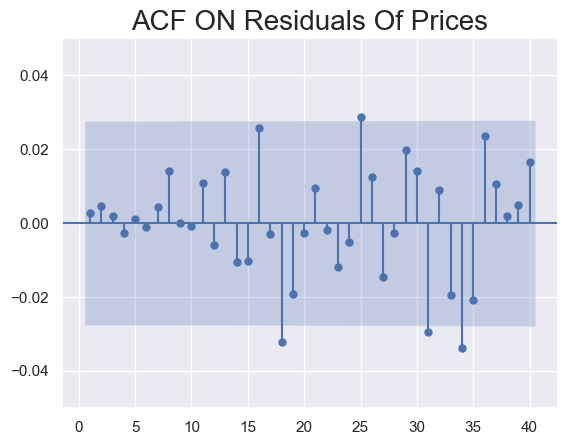

In [83]:
sgt.plot_acf(df.resid_price, lags=40,zero=False)
plt.title("ACF ON Residuals Of Prices",size=20)
plt.ylim(-.05,.05)
plt.show()

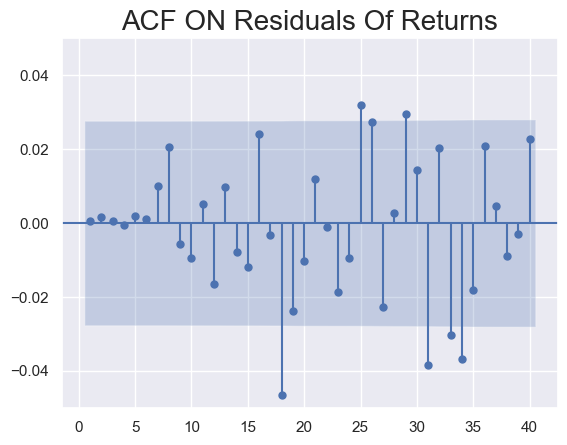

In [82]:
sgt.plot_acf(df.resid_returns, lags=40,zero=False)
plt.title("ACF ON Residuals Of Returns",size=20)
plt.ylim(-.05,.05)
plt.show()

`ACF Of Rsiduals on both price and returns tells us that most of the coefficients lie inside the significance level`      
 
`implies that they are no other than 0, thus residuals mimic White noise data`                                            

`Except for a few points where it is significant which implies -> There is an even better Model which we can fit`

### Plotting the Data of Residuals of Prices and Returns 

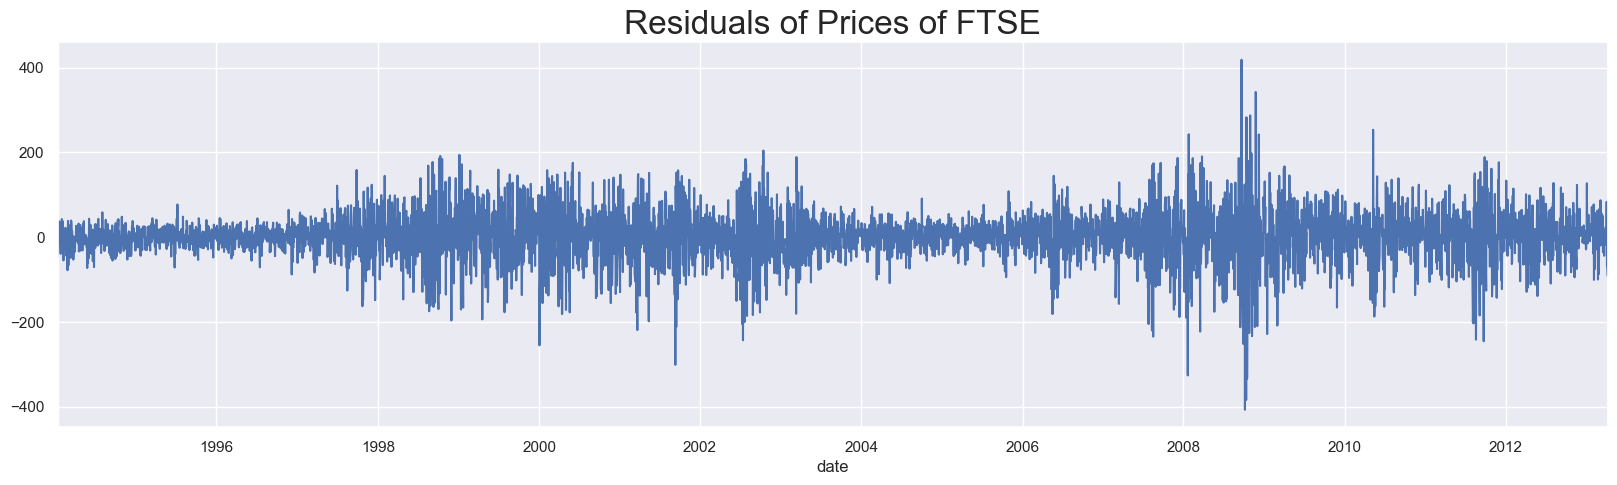

In [85]:
# Residuals of Prices
df.resid_price[1:].plot(figsize=(20,5))
plt.title("Residuals of Prices of FTSE",size=24)
plt.show()

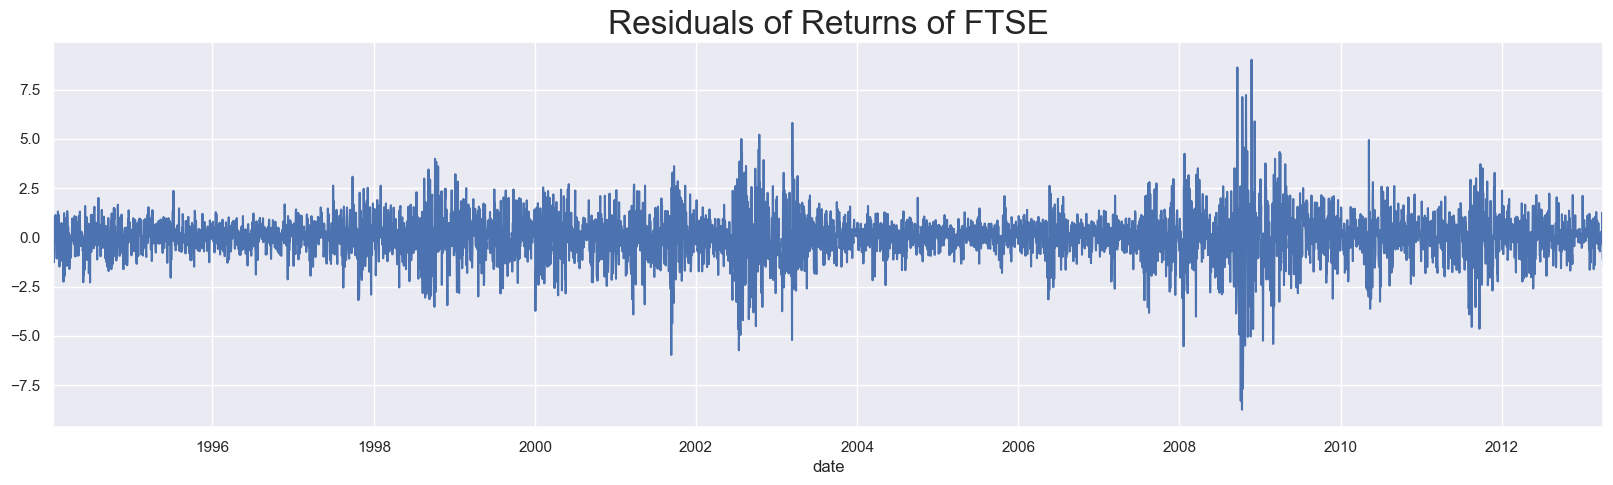

In [88]:
df.resid_returns.plot(figsize=(20,5))
plt.title("Residuals of Returns of FTSE",size=24)
plt.show()

In [86]:
df.resid_price

date
1994-01-10   -1649.388287
1994-01-11     -29.933468
1994-01-12     -45.328481
1994-01-13     -17.115247
1994-01-14      33.397636
                 ...     
2013-04-01       1.407479
2013-04-02      83.386402
2013-04-03     -66.835216
2013-04-04     -71.064930
2013-04-05     -90.353358
Freq: B, Name: resid_price, Length: 5020, dtype: float64

In [87]:
df.resid_returns

date
1994-01-10   -0.175618
1994-01-11   -0.802193
1994-01-12   -1.270020
1994-01-13   -0.466050
1994-01-14    1.061293
                ...   
2013-04-01   -0.044015
2013-04-02    1.257867
2013-04-03   -1.089305
2013-04-04   -1.157463
2013-04-05   -1.471438
Freq: B, Name: resid_returns, Length: 5020, dtype: float64